## 1.Bibliotecas

In [24]:
import yfinance as yf
import pandas as pd
import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# 2. Composição histórica do ibov

In [9]:
# Lista dos ativos fornecidos (somente os tickers)
tickers_ibov = [
    "ALOS3", "ALPA4", "ABEV3", "ASAI3", "AURE3", "AZUL4", "AZZA3", "B3SA3", "BBSE3",
    "BBDC3", "BBDC4", "BRAP4", "BBAS3", "BRKM5", "BRAV3", "BRFS3", "BPAC11", "CXSE3",
    "CRFB3", "CCRO3", "CMIG4", "COGN3", "CPLE6", "CSAN3", "CPFE3", "CMIN3", "CVCB3",
    "CYRE3", "ELET3", "ELET6", "EMBR3", "ENGI11", "ENEV3", "EGIE3", "EQTL3", "EZTC3",
    "FLRY3", "GGBR4", "GOAU4", "NTCO3", "HAPV3", "HYPE3", "IGTI11", "IRBR3", "ITSA4",
    "ITUB4", "JBSS3", "KLBN11", "RENT3", "LREN3", "LWSA3", "MGLU3", "MRFG3", "BEEF3",
    "MRVE3", "MULT3", "PCAR3", "PETR3", "PETR4", "RECV3", "PRIO3", "PETZ3", "RADL3",
    "RAIZ4", "RDOR3", "RAIL3", "SBSP3", "SANB11", "STBP3", "SMTO3", "CSNA3", "SLCE3",
    "SUZB3", "TAEE11", "VIVT3", "TIMS3", "TOTS3", "TRPL4", "UGPA3", "USIM5", "VALE3",
    "VAMO3", "VBBR3", "VIVA3", "WEGE3", "YDUQ3"
]

# Definindo o intervalo de tempo para coleta dos preços
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=20*365)  # Aproximadamente 20 anos atrás

# Inicializar um DataFrame vazio para armazenar todos os preços
all_prices = pd.DataFrame()

# Loop para coletar os preços de cada ativo
for ticker in tickers_ibov:
    try:
        print(f"Baixando os preços para o ativo: {ticker}")
        # Download dos preços históricos para cada ativo
        data = yf.download(ticker + ".SA", start=start_date, end=end_date)

        # Manter apenas a coluna 'Close' e renomear para o ticker
        data = data[['Close']]
        data.columns = [ticker]

        # Juntar ao DataFrame principal
        if all_prices.empty:
            all_prices = data
        else:
            all_prices = all_prices.join(data, how='outer')
    
    except Exception as e:
        print(f"Erro ao coletar dados para {ticker}: {e}")

Baixando os preços para o ativo: ALOS3


[*********************100%***********************]  1 of 1 completed


Baixando os preços para o ativo: ALPA4


[*********************100%***********************]  1 of 1 completed


Baixando os preços para o ativo: ABEV3


...

[*********************100%***********************]  1 of 1 completed


Baixando os preços para o ativo: WEGE3


[*********************100%***********************]  1 of 1 completed


Baixando os preços para o ativo: YDUQ3


[*********************100%***********************]  1 of 1 completed


In [12]:
# Exibir as primeiras linhas do resultado
display(all_prices)

,ALOS3,ALPA4,ABEV3,ASAI3,AURE3,AZUL4,AZZA3,B3SA3,BBSE3,BBDC3,...,TOTS3,TRPL4,UGPA3,USIM5,VALE3,VAMO3,VBBR3,VIVA3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2004-10-11,NaN,NaN,3.955959,NaN,NaN,NaN,NaN,NaN,NaN,2.388197,...,NaN,12298.770508,6.068052e+06,10.188888,15.925000,NaN,NaN,NaN,1.020710,NaN
2004-10-12,NaN,NaN,3.955959,NaN,NaN,NaN,NaN,NaN,NaN,2.388197,...,NaN,12298.770508,6.068052e+06,10.188888,15.925000,NaN,NaN,NaN,1.020710,NaN
2004-10-13,NaN,NaN,4.077963,NaN,NaN,NaN,NaN,NaN,NaN,2.397347,...,NaN,11998.799805,6.068052e+06,9.922222,14.800000,NaN,NaN,NaN,1.020710,NaN
2004-10-14,NaN,NaN,4.180128,NaN,NaN,NaN,NaN,NaN,NaN,2.397347,...,NaN,11768.823242,6.068052e+06,9.711111,14.625000,NaN,NaN,NaN,1.020710,NaN
2004-10-15,NaN,NaN,4.203202,NaN,NaN,NaN,NaN,NaN,NaN,2.454079,...,NaN,12088.791016,6.068052e+06,9.755555,15.450000,NaN,NaN,NaN,1.020710,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30,21.850000,6.95,13.080000,7.47,10.46,6.24,42.169998,10.71,35.500000,13.090000,...,28.559999,24.299999,2.121000e+01,6.240000,63.509998,6.61,23.400000,26.930000,54.389999,9.19
2024-10-01,21.860001,6.92,13.600000,7.12,10.48,5.95,41.759998,10.71,35.750000,12.980000,...,28.660000,24.260000,2.140000e+01,6.240000,63.820000,6.46,23.280001,27.580000,55.880001,9.04
2024-10-02,22.209999,7.13,13.720000,7.15,10.43,6.24,42.330002,10.94,35.459999,13.380000,...,29.450001,24.430000,2.149000e+01,6.310000,64.169998,6.03,23.389999,28.280001,55.349998,9.22


In [11]:
# Salvar os dados em um arquivo CSV para uso posterior
all_prices.to_csv("precos_historicos_ibov.csv")


In [17]:

# Definir o índice IBOV para cálculos de correlação e beta
ibov_prices = yf.download("^BVSP", start=all_prices.index.min(), end=all_prices.index.max())['Close']

# Inicializar lista para armazenar os resultados
analysis_results = []

# Calcular métricas financeiras para cada ativo
for ticker in all_prices.columns:
    data = all_prices[ticker].dropna()  # Remover NaN

    # Cálculo de retornos diários
    daily_returns = data.pct_change().dropna()

    # Cálculo de retornos acumulados
    last_1m = (data.iloc[-1] / data[-22] - 1) if len(data) > 22 else np.nan  # 22 dias de negociação no último mês
    last_6m = (data.iloc[-1] / data[-132] - 1) if len(data) > 132 else np.nan  # 132 dias de negociação nos últimos 6 meses
    last_1y = (data.iloc[-1] / data[-252] - 1) if len(data) > 252 else np.nan  # 252 dias de negociação no último ano
    last_5y = (data.iloc[-1] / data[-1260] - 1) if len(data) > 1260 else np.nan  # 1260 dias de negociação nos últimos 5 anos
    last_10y = (data.iloc[-1] / data[-2520] - 1) if len(data) > 2520 else np.nan  # 2520 dias de negociação nos últimos 10 anos

    # Cálculo da média de retorno anualizado e volatilidade
    mean_return = daily_returns.mean() * 252  # Anualizado (252 dias de negociação)
    volatility = daily_returns.std() * np.sqrt(252)  # Anualizado

    # Índice Sharpe (assumindo retorno livre de risco de 3%)
    risk_free_rate = 0.03
    sharpe_ratio = (mean_return - risk_free_rate) / volatility

    # Cálculo do beta ajustado para alinhar as datas entre o ativo e o IBOV
    ibov_returns = ibov_prices.pct_change().dropna()

    # Encontrar as datas em comum entre os retornos do ativo e os retornos do IBOV
    common_dates = daily_returns.index.intersection(ibov_returns.index)
    aligned_daily_returns = daily_returns.loc[common_dates]
    aligned_ibov_returns = ibov_returns.loc[common_dates]

    # Calcular a covariância usando os retornos alinhados
    if not aligned_daily_returns.empty and not aligned_ibov_returns.empty:
        covariance = np.cov(aligned_daily_returns, aligned_ibov_returns)[0][1]
        beta = covariance / aligned_ibov_returns.var()
    else:
        beta = np.nan

    # Cálculo do VaR histórico (95% de confiança)
    VaR_95 = np.percentile(daily_returns, 5)

    # Correlação com o IBOV (últimos 5 anos)
    last_5_years_data = data[data.index >= (datetime.datetime.now() - datetime.timedelta(days=5*365))]
    if not last_5_years_data.empty:
        correlation_with_ibov = last_5_years_data.pct_change().corr(ibov_prices.pct_change())
    else:
        correlation_with_ibov = np.nan

    # Obter setor do ativo

    # Armazenar os resultados em um dicionário
    analysis_results.append({
        "Ticker": ticker,
        "Retorno Médio Anualizado": mean_return,
        "Volatilidade Anualizada": volatility,
        "Retorno Último Mês": last_1m,
        "Retorno Últimos 6 Meses": last_6m,
        "Retorno Últimos 12 Meses": last_1y,
        "Retorno Últimos 5 Anos": last_5y,
        "Retorno Últimos 10 Anos": last_10y,
        "Sharpe Ratio": sharpe_ratio,
        "Beta": beta,
        "VaR 95%": VaR_95,
        "Correlação com IBOV (Últimos 5 Anos)": correlation_with_ibov
    })

[*********************100%***********************]  1 of 1 completed
C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\799678502.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_1m = (data.iloc[-1] / data[-22] - 1) if len(data) > 22 else np.nan  # 22 dias de negociação no último mês
C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\799678502.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_6m = (data.iloc[-1] / data[-132] - 1) if len(data) > 132 else np.nan  # 132 dias de negociação nos últimos 6 meses
C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\799678502.py:17: FutureWarning: Series.__getitem

   Ticker  Retorno Médio Anualizado  Volatilidade Anualizada  \
0   ALOS3                  0.049659                 0.227479   
1   ALPA4                  0.119490                 0.404079   
2   ABEV3                  0.100031                 0.276742   
3   ASAI3                 -0.129279                 0.378551   
4   AURE3                 -0.155804                 0.235025   
..    ...                       ...                      ...   
81  VAMO3                  0.016176                 0.477319   
82  VBBR3                  0.086481                 0.408818   
83  VIVA3                  0.164544                 0.512411   
84  WEGE3                  0.257463                 0.335479   
85  YDUQ3                  0.138349                 0.496425   

    Retorno Último Mês  Retorno Últimos 6 Meses  Retorno Últimos 12 Meses  \
0            -0.033090                -0.049831                       NaN   
1            -0.071146                -0.245989                 -0.131773   


In [18]:
# Converter a lista de resultados em um DataFrame
analysis_df = pd.DataFrame(analysis_results)

# Exibir as primeiras linhas do DataFrame de análise
display(analysis_df)

,Ticker,Retorno Médio Anualizado,Volatilidade Anualizada,Retorno Último Mês,Retorno Últimos 6 Meses,Retorno Últimos 12 Meses,Retorno Últimos 5 Anos,Retorno Últimos 10 Anos,Sharpe Ratio,Beta,VaR 95%,Correlação com IBOV (Últimos 5 Anos)
0,ALOS3,0.049659,0.227479,-0.033090,-0.049831,NaN,NaN,NaN,0.086420,1.139148,-0.021891,0.631006
1,ALPA4,0.119490,0.404079,-0.071146,-0.245989,-0.131773,-0.691093,-0.165629,0.221467,0.642817,-0.036912,0.523359
2,ABEV3,0.100031,0.276742,0.023901,0.082315,0.005299,-0.304712,-0.182769,0.253056,0.525801,-0.025307,0.592109
3,ASAI3,-0.129279,0.378551,-0.273201,-0.502853,-0.400688,NaN,NaN,-0.420760,0.879662,-0.036615,0.421384
4,AURE3,-0.155804,0.235025,-0.088183,-0.140482,-0.239706,NaN,NaN,-0.790572,0.427590,-0.022938,0.317693
...,...,...,...,...,...,...,...,...,...,...,...,...
81,VAMO3,0.016176,0.477319,-0.265625,-0.300248,-0.355429,NaN,NaN,-0.028962,1.431998,-0.051876,0.549908
82,VBBR3,0.086481,0.408818,-0.128679,-0.090587,0.213347,-0.153903,NaN,0.138157,1.098600,-0.037396,0.707473
83,VIVA3,0.164544,0.512411,-0.005029,0.112897,0.014281,NaN,NaN,0.262571,1.287112,-0.040003,0.646871
84,WEGE3,0.257463,0.335479,0.009446,0.427823,0.550057,3.595278,9.674200,0.678022,0.553172,-0.030660,0.529837


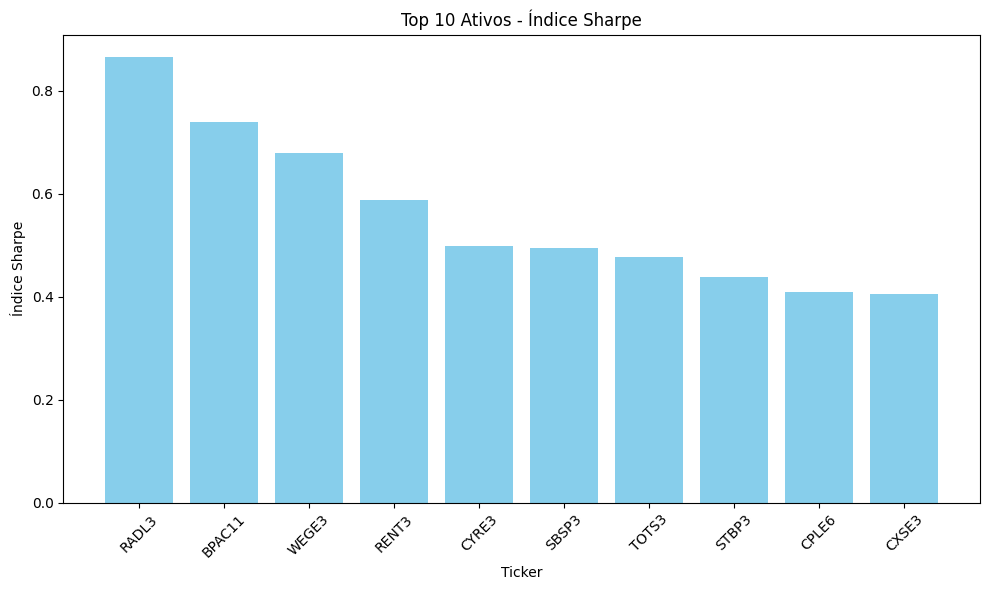

In [21]:
# Ordenar os dados e selecionar os 10 melhores para cada métrica
top_10_sharpe = analysis_df.sort_values(by="Sharpe Ratio", ascending=False).head(10)
top_10_volatility = analysis_df.sort_values(by="Volatilidade Anualizada", ascending=False).head(10)

# Configurar a visualização dos gráficos

# Gráfico dos 10 ativos com melhor índice Sharpe
plt.figure(figsize=(10, 6))
plt.bar(top_10_sharpe['Ticker'], top_10_sharpe['Sharpe Ratio'], color='skyblue')
plt.xlabel('Ticker')
plt.ylabel('Índice Sharpe')
plt.title('Top 10 Ativos - Índice Sharpe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_10_sharpe.png')  # Salvar gráfico como imagem
plt.show()

[*********************100%***********************]  1 of 1 completed


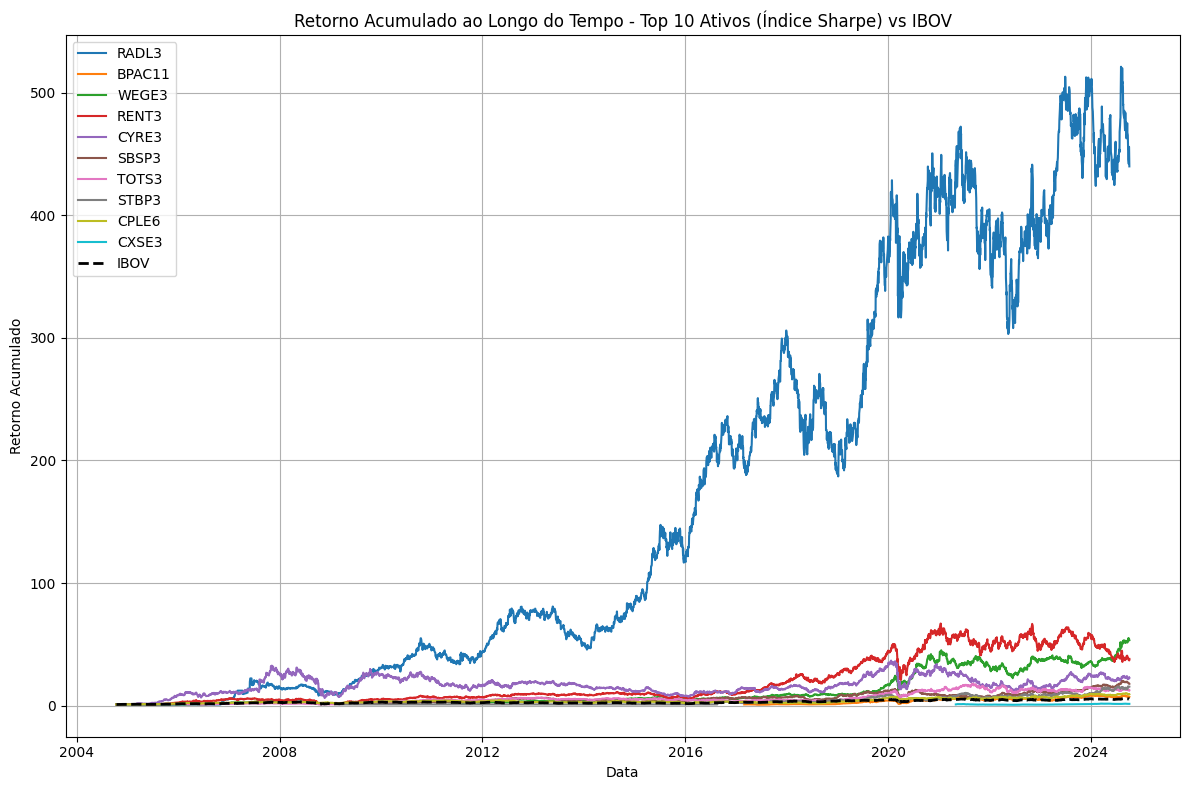

In [22]:
# Carregar o arquivo CSV com a análise dos ativos e os preços históricos
prices_df = all_prices

# Selecionar os 10 ativos com melhor índice Sharpe
top_10_sharpe = analysis_df.sort_values(by="Sharpe Ratio", ascending=False).head(10)['Ticker']

# Inicializar um DataFrame para armazenar os retornos acumulados dos 10 melhores ativos
cumulative_returns_df = pd.DataFrame()

# Calcular o retorno acumulado para cada ativo
for ticker in top_10_sharpe:
    # Certifique-se de que o ticker esteja presente no DataFrame de preços
    if ticker in prices_df.columns:
        # Calcular os retornos diários
        daily_returns = prices_df[ticker].pct_change().dropna()
        # Calcular o retorno acumulado
        cumulative_return = (1 + daily_returns).cumprod()
        # Adicionar ao DataFrame
        cumulative_returns_df[ticker] = cumulative_return

# Baixar os preços históricos do IBOV para o mesmo período
ibov_prices = yf.download("^BVSP", start=prices_df.index.min(), end=prices_df.index.max())['Close']

# Calcular o retorno acumulado do IBOV
ibov_daily_returns = ibov_prices.pct_change().dropna()
ibov_cumulative_return = (1 + ibov_daily_returns).cumprod()

# Configurar o gráfico para mostrar os retornos acumulados
plt.figure(figsize=(12, 8))

# Plotar o retorno acumulado dos 10 melhores ativos
for ticker in cumulative_returns_df.columns:
    plt.plot(cumulative_returns_df.index, cumulative_returns_df[ticker], label=ticker)

# Plotar o retorno acumulado do IBOV
plt.plot(ibov_cumulative_return.index, ibov_cumulative_return, label="IBOV", color='black', linewidth=2, linestyle='--')

# Customização do gráfico
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado')
plt.title('Retorno Acumulado ao Longo do Tempo - Top 10 Ativos (Índice Sharpe) vs IBOV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('top_10_cumulative_returns_vs_ibov.png')  # Salvar o gráfico como imagem
plt.show()

C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\1412020789.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = prices_df[top_10_sharpe].pct_change().dropna()
[*********************100%***********************]  1 of 1 completed


Pesos Otimizados da Carteira:
ITUB4    4.844424e-05
VALE3    8.583824e-02
B3SA3    2.296209e-07
WEGE3    2.048126e-01
ABEV3    4.207810e-01
PETR4    1.380308e-06
PETR3    2.119223e-07
EQTL3    2.018551e-01
BBAS3    1.039724e-07
ITSA4    8.666273e-02
dtype: float64


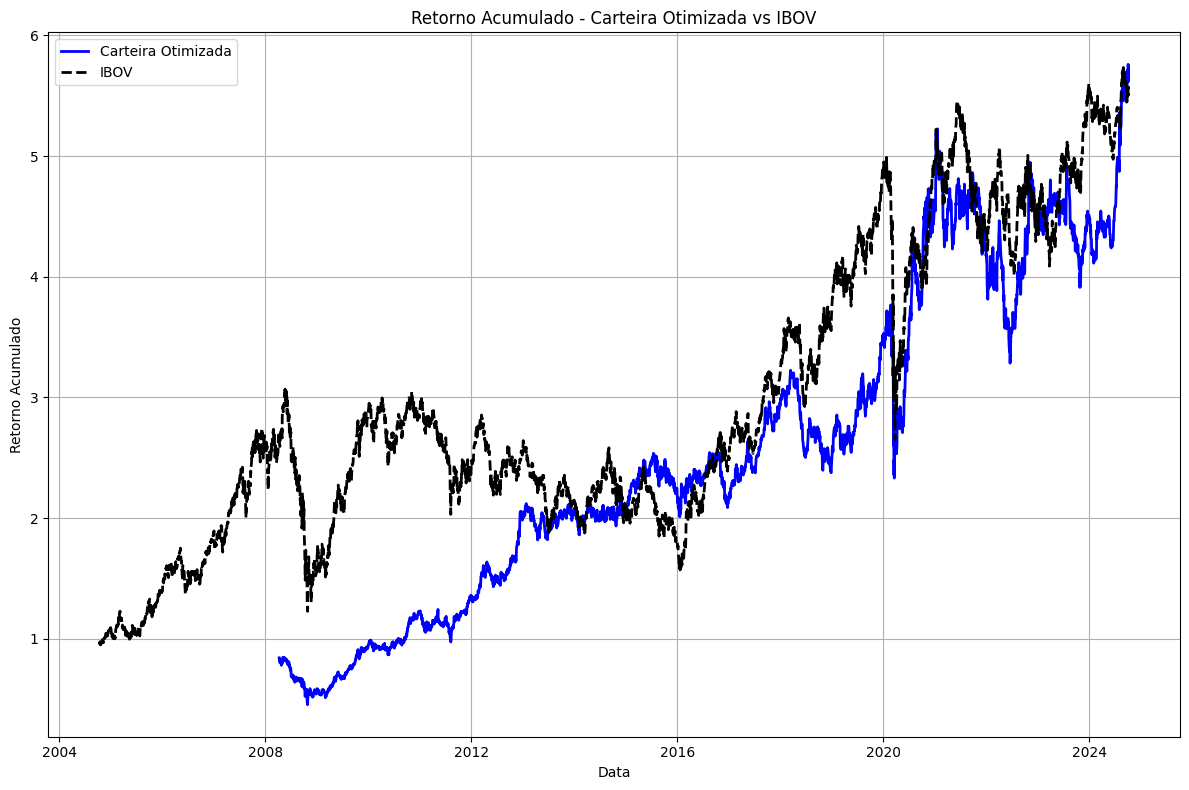

In [25]:
# Selecionar os 10 ativos com melhor índice Sharpe, previamente analisados
top_10_sharpe = ["ITUB4", "VALE3", "B3SA3", "WEGE3", "ABEV3", "PETR4", "PETR3", "EQTL3", "BBAS3", "ITSA4"]

# Calcular os retornos diários para cada ativo
returns_df = prices_df[top_10_sharpe].pct_change().dropna()

# Calcular o retorno médio anualizado e a matriz de covariância anualizada
mean_returns = returns_df.mean() * 252  # Anualizado (252 dias de negociação)
cov_matrix = returns_df.cov() * 252  # Anualizado

# Converter os retornos e a matriz de covariância para formato de matriz do cvxopt
n = len(top_10_sharpe)
P = matrix(np.array(cov_matrix))  # Matriz de covariância (Quadrática)
q = matrix(np.zeros(n))  # Vetor para função objetivo (minimizar risco)

# Restrições: a soma das alocações deve ser igual a 1, e todas as alocações >= 0
# Gx <= h, com G para desigualdade de não negatividade (-x <= 0)
G = matrix(-np.eye(n))  # Matriz identidade negativa para garantir x >= 0
h = matrix(np.zeros(n))

# A soma dos pesos deve ser igual a 1 (Ax = b)
A = matrix(1.0, (1, n))  # Um vetor de 1s para garantir a soma das alocações
b = matrix(1.0)  # A soma das alocações deve ser 1

# Resolver o problema de otimização
solvers.options['show_progress'] = False  # Desabilitar saída detalhada
sol = solvers.qp(P, q, G, h, A, b)
weights = np.array(sol['x']).flatten()  # Pesos otimizados

# Exibir os pesos otimizados para cada ativo
portfolio_weights = pd.Series(weights, index=top_10_sharpe)
print("Pesos Otimizados da Carteira:")
print(portfolio_weights)

# Calcular o retorno acumulado da carteira otimizada
cumulative_returns_df = (1 + returns_df).cumprod()
portfolio_cumulative_return = (cumulative_returns_df * weights).sum(axis=1)

# Baixar os preços históricos do IBOV para o mesmo período
ibov_prices = yf.download("^BVSP", start=prices_df.index.min(), end=prices_df.index.max())['Close']
ibov_returns = ibov_prices.pct_change().dropna()
ibov_cumulative_return = (1 + ibov_returns).cumprod()

# Plotar o retorno acumulado da carteira otimizada vs IBOV
plt.figure(figsize=(12, 8))
plt.plot(portfolio_cumulative_return.index, portfolio_cumulative_return, label="Carteira Otimizada", color='blue', linewidth=2)
plt.plot(ibov_cumulative_return.index, ibov_cumulative_return, label="IBOV", color='black', linestyle='--', linewidth=2)
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado')
plt.title('Retorno Acumulado - Carteira Otimizada vs IBOV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('portfolio_optimized_vs_ibov.png')  # Salvar o gráfico como imagem
plt.show()

C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\2073606043.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = prices_df[top_10_sharpe].pct_change().dropna()
C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\2073606043.py:17: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(start=start_date, end=end_date, freq=f'{window_years}Y')
[*********************100%***********************]  1 of 1 completed


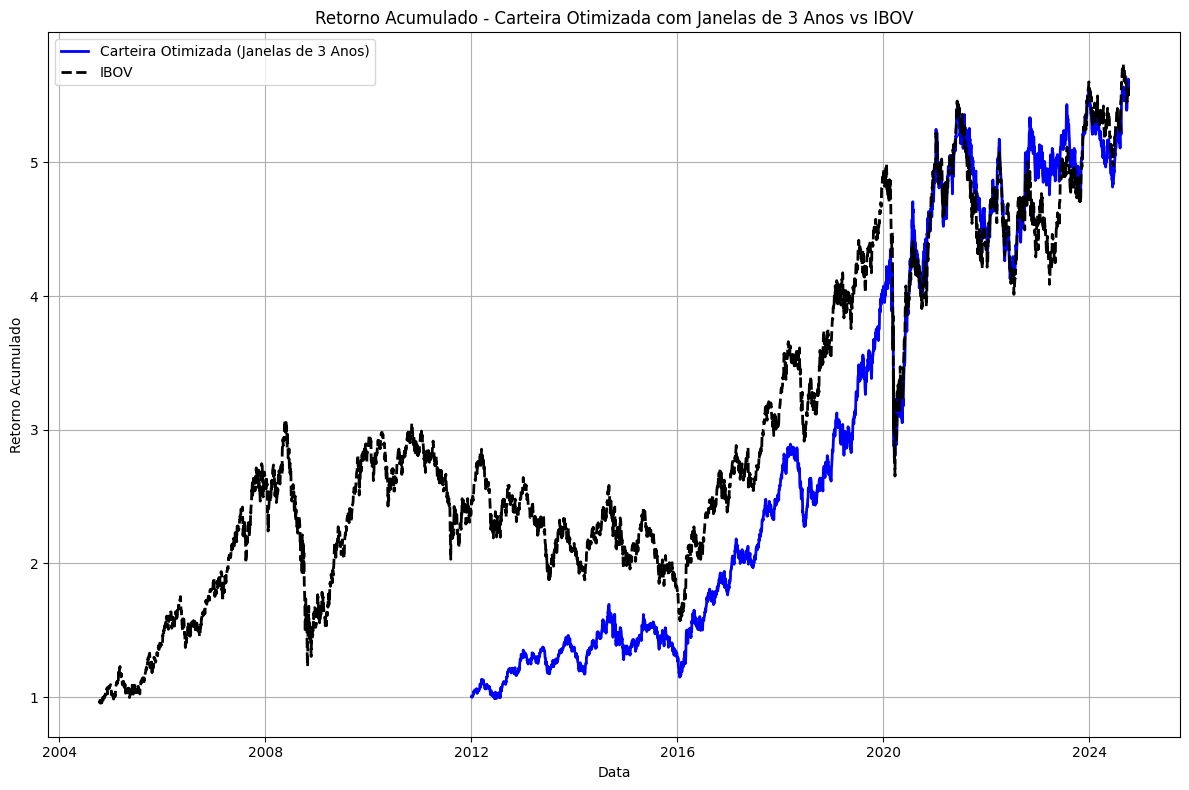

In [35]:
# Selecionar os 10 ativos com melhor índice Sharpe, previamente analisados
top_10_sharpe = ["ITUB4", "VALE3", "B3SA3", "WEGE3", "ABEV3", "PETR4", "PETR3", "EQTL3", "BBAS3", "ITSA4"]

# Calcular os retornos diários para cada ativo
returns_df = prices_df[top_10_sharpe].pct_change().dropna()

# Parâmetros de otimização
max_weight = 0.20  # Limite máximo para o peso de cada ativo (20%)
window_years = 3  # Duração da janela em anos

# Inicializar uma lista para armazenar os retornos acumulados da carteira otimizada
portfolio_cumulative_returns_list = []

# Obter as datas de início e fim para cada janela de tempo de 3 anos
start_date = returns_df.index.min()
end_date = returns_df.index.max()
dates = pd.date_range(start=start_date, end=end_date, freq=f'{window_years}Y')

# Iterar sobre cada janela de tempo de 3 anos
for i in range(len(dates) - 1):
    # Definir a janela de treinamento e a janela de alocação
    train_start = dates[i]
    train_end = dates[i + 1] - pd.Timedelta(days=1)
    allocation_start = dates[i + 1]
    allocation_end = dates[i + 2] - pd.Timedelta(days=1) if i + 2 < len(dates) else end_date

    # Calcular a média de retornos e a matriz de covariância da janela de treinamento (3 anos)
    train_data = returns_df[(returns_df.index >= train_start) & (returns_df.index <= train_end)]
    if train_data.empty:
        print(f"Aviso: Janela de treinamento vazia para o período {train_start} a {train_end}")
        continue  # Pular a janela se não houver dados suficientes para treinamento
    
    mean_returns = train_data.mean() * 252  # Anualizado
    cov_matrix = train_data.cov() * 252  # Anualizado

    # Converter para formato compatível com cvxopt
    n = len(top_10_sharpe)
    P = matrix(np.array(cov_matrix))  # Matriz de covariância
    q = matrix(np.zeros(n))  # Vetor para função objetivo

    # Restrições: a soma das alocações deve ser 1, e cada alocação deve ser >= 0 e <= max_weight
    G = matrix(np.vstack((-np.eye(n), np.eye(n))))  # Combina restrições de não negatividade e limite máximo
    h = matrix(np.hstack((np.zeros(n), np.ones(n) * max_weight)))
    A = matrix(1.0, (1, n))
    b = matrix(1.0)

    # Resolver o problema de otimização
    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)
    weights = np.array(sol['x']).flatten()

    # Aplicar os pesos otimizados à janela de alocação e calcular o retorno acumulado
    allocation_data = returns_df[(returns_df.index >= allocation_start) & (returns_df.index <= allocation_end)]
    if allocation_data.empty:
        print(f"Aviso: Janela de alocação vazia para o período {allocation_start} a {allocation_end}")
        continue  # Pular a janela se não houver dados suficientes para alocação

    weighted_returns = (allocation_data * weights).sum(axis=1)
    cumulative_returns = (1 + weighted_returns).cumprod()

    # Ajustar o valor inicial do retorno acumulado para continuar da última janela
    if portfolio_cumulative_returns_list:
        last_value = portfolio_cumulative_returns_list[-1].iloc[-1]
        cumulative_returns *= last_value

    portfolio_cumulative_returns_list.append(cumulative_returns)

# Verificar se existem objetos para concatenar
if portfolio_cumulative_returns_list:
    # Concatenar os retornos acumulados ao longo das janelas
    portfolio_cumulative_returns = pd.concat(portfolio_cumulative_returns_list)
else:
    print("Erro: Nenhuma janela válida foi encontrada para otimização.")

# Baixar os preços históricos do IBOV para o mesmo período
ibov_prices = yf.download("^BVSP", start=prices_df.index.min(), end=prices_df.index.max())['Close']
ibov_returns = ibov_prices.pct_change().dropna()
ibov_cumulative_return = (1 + ibov_returns).cumprod()

# Plotar o retorno acumulado da carteira otimizada vs IBOV
if not portfolio_cumulative_returns_list:
    print("Erro: Não há retornos acumulados disponíveis para plotagem.")
else:
    plt.figure(figsize=(12, 8))
    plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns, label="Carteira Otimizada (Janelas de 3 Anos)", color='blue', linewidth=2)
    plt.plot(ibov_cumulative_return.index, ibov_cumulative_return, label="IBOV", color='black', linestyle='--', linewidth=2)
    plt.xlabel('Data')
    plt.ylabel('Retorno Acumulado')
    plt.title('Retorno Acumulado - Carteira Otimizada com Janelas de 3 Anos vs IBOV')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('portfolio_optimized_vs_ibov_windowed_3y.png')  # Salvar o gráfico como imagem
    plt.show()


In [31]:
print(portfolio_cumulative_returns)

Series([], dtype: float64)


C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\1912548765.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = prices_df[top_10_sharpe].pct_change().dropna()
C:\Users\ribei\AppData\Local\Temp\ipykernel_24304\1912548765.py:22: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(start=start_date, end=end_date, freq=f'{window_years}Y')


<Figure size 1000x800 with 0 Axes>

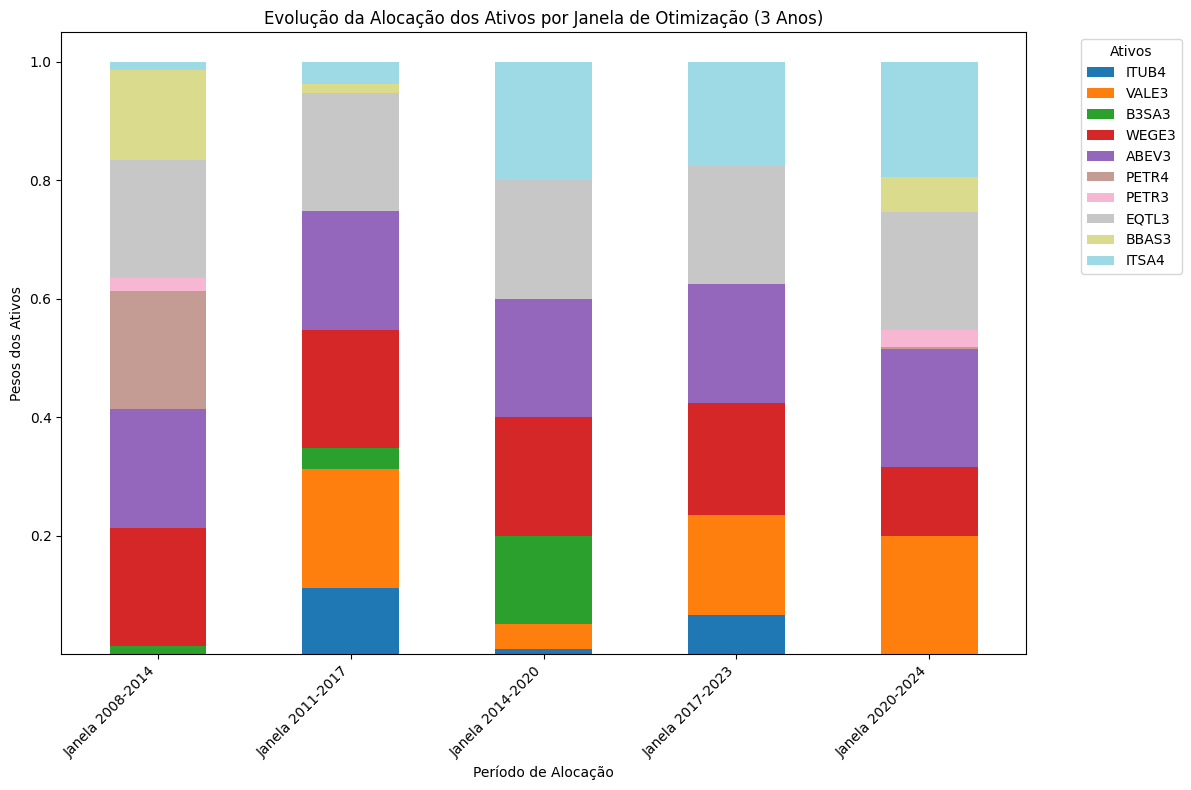

[*********************100%***********************]  1 of 1 completed


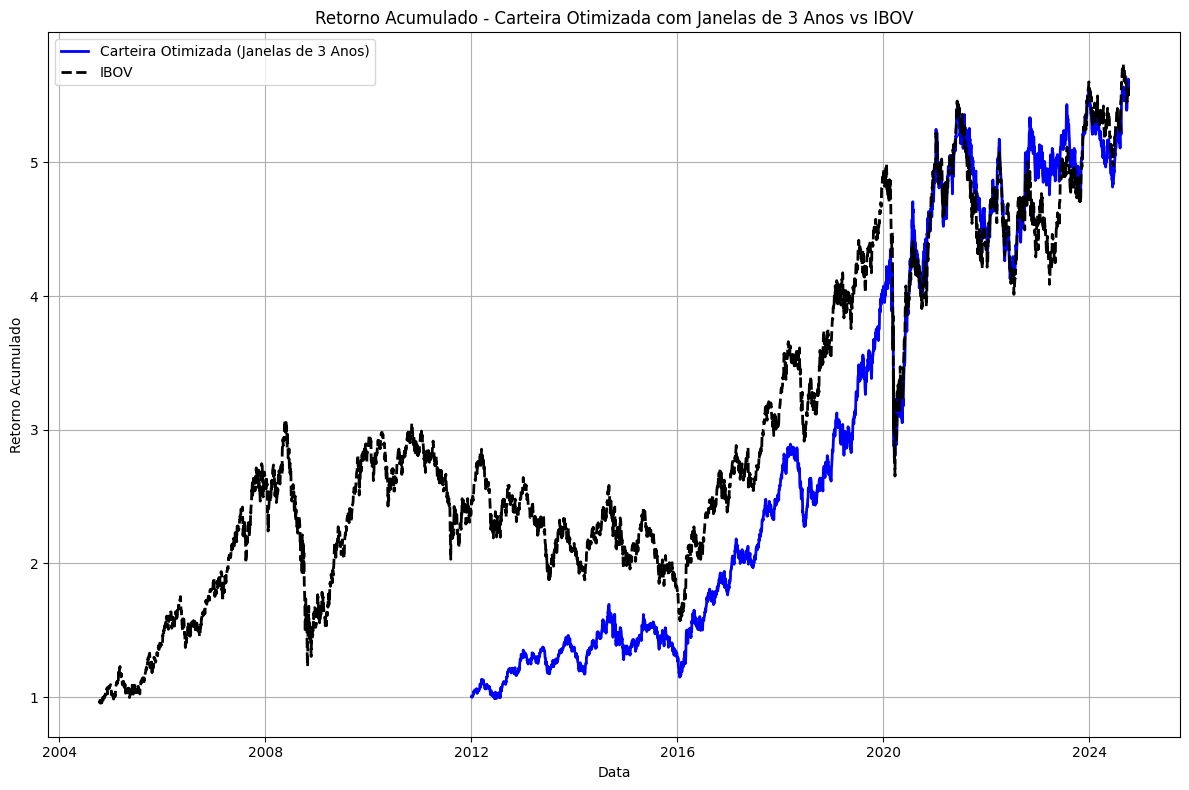

In [36]:
# Carregar o arquivo CSV com os preços históricos
prices_df = pd.read_csv("precos_historicos_ibov.csv", index_col=0, parse_dates=True)

# Selecionar os 10 ativos com melhor índice Sharpe, previamente analisados
top_10_sharpe = ["ITUB4", "VALE3", "B3SA3", "WEGE3", "ABEV3", "PETR4", "PETR3", "EQTL3", "BBAS3", "ITSA4"]

# Calcular os retornos diários para cada ativo
returns_df = prices_df[top_10_sharpe].pct_change().dropna()

# Parâmetros de otimização
max_weight = 0.20  # Limite máximo para o peso de cada ativo (20%)
window_years = 3  # Duração da janela em anos

# Inicializar uma lista para armazenar os retornos acumulados da carteira otimizada
portfolio_cumulative_returns_list = []
# Inicializar uma lista para armazenar os pesos dos ativos em cada janela
weights_list = []

# Obter as datas de início e fim para cada janela de tempo de 3 anos
start_date = returns_df.index.min()
end_date = returns_df.index.max()
dates = pd.date_range(start=start_date, end=end_date, freq=f'{window_years}Y')

# Iterar sobre cada janela de tempo de 3 anos
for i in range(len(dates) - 1):
    # Definir a janela de treinamento e a janela de alocação
    train_start = dates[i]
    train_end = dates[i + 1] - pd.Timedelta(days=1)
    allocation_start = dates[i + 1]
    allocation_end = dates[i + 2] - pd.Timedelta(days=1) if i + 2 < len(dates) else end_date

    # Calcular a média de retornos e a matriz de covariância da janela de treinamento (3 anos)
    train_data = returns_df[(returns_df.index >= train_start) & (returns_df.index <= train_end)]
    if train_data.empty:
        print(f"Aviso: Janela de treinamento vazia para o período {train_start} a {train_end}")
        continue  # Pular a janela se não houver dados suficientes para treinamento
    
    mean_returns = train_data.mean() * 252  # Anualizado
    cov_matrix = train_data.cov() * 252  # Anualizado

    # Converter para formato compatível com cvxopt
    n = len(top_10_sharpe)
    P = matrix(np.array(cov_matrix))  # Matriz de covariância
    q = matrix(np.zeros(n))  # Vetor para função objetivo

    # Restrições: a soma das alocações deve ser 1, e cada alocação deve ser >= 0 e <= max_weight
    G = matrix(np.vstack((-np.eye(n), np.eye(n))))  # Combina restrições de não negatividade e limite máximo
    h = matrix(np.hstack((np.zeros(n), np.ones(n) * max_weight)))
    A = matrix(1.0, (1, n))
    b = matrix(1.0)

    # Resolver o problema de otimização
    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)
    weights = np.array(sol['x']).flatten()

    # Salvar os pesos dos ativos para a janela atual
    weights_list.append(pd.Series(weights, index=top_10_sharpe, name=f"Janela {train_start.year}-{allocation_end.year}"))

    # Aplicar os pesos otimizados à janela de alocação e calcular o retorno acumulado
    allocation_data = returns_df[(returns_df.index >= allocation_start) & (returns_df.index <= allocation_end)]
    if allocation_data.empty:
        print(f"Aviso: Janela de alocação vazia para o período {allocation_start} a {allocation_end}")
        continue  # Pular a janela se não houver dados suficientes para alocação

    weighted_returns = (allocation_data * weights).sum(axis=1)
    cumulative_returns = (1 + weighted_returns).cumprod()

    # Ajustar o valor inicial do retorno acumulado para continuar da última janela
    if portfolio_cumulative_returns_list:
        last_value = portfolio_cumulative_returns_list[-1].iloc[-1]
        cumulative_returns *= last_value

    portfolio_cumulative_returns_list.append(cumulative_returns)

# Verificar se existem objetos para concatenar
if portfolio_cumulative_returns_list:
    # Concatenar os retornos acumulados ao longo das janelas
    portfolio_cumulative_returns = pd.concat(portfolio_cumulative_returns_list)
else:
    print("Erro: Nenhuma janela válida foi encontrada para otimização.")

# Criar um DataFrame com os pesos dos ativos para cada janela
weights_df = pd.concat(weights_list, axis=1)

# Plotar a alocação dos ativos em cada janela de otimização
plt.figure(figsize=(10, 8))
weights_df.T.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 8))
plt.xlabel('Período de Alocação')
plt.ylabel('Pesos dos Ativos')
plt.title('Evolução da Alocação dos Ativos por Janela de Otimização (3 Anos)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ativos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('portfolio_allocation_per_window.png')  # Salvar o gráfico como imagem
plt.show()

# Baixar os preços históricos do IBOV para o mesmo período
ibov_prices = yf.download("^BVSP", start=prices_df.index.min(), end=prices_df.index.max())['Close']
ibov_returns = ibov_prices.pct_change().dropna()
ibov_cumulative_return = (1 + ibov_returns).cumprod()

# Plotar o retorno acumulado da carteira otimizada vs IBOV
if not portfolio_cumulative_returns_list:
    print("Erro: Não há retornos acumulados disponíveis para plotagem.")
else:
    plt.figure(figsize=(12, 8))
    plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns, label="Carteira Otimizada (Janelas de 3 Anos)", color='blue', linewidth=2)
    plt.plot(ibov_cumulative_return.index, ibov_cumulative_return, label="IBOV", color='black', linestyle='--', linewidth=2)
    plt.xlabel('Data')
    plt.ylabel('Retorno Acumulado')
    plt.title('Retorno Acumulado - Carteira Otimizada com Janelas de 3 Anos vs IBOV')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('portfolio_optimized_vs_ibov_windowed_3y.png')  # Salvar o gráfico como imagem
    plt.show()
